# Hypothesis Testing for LLM Evaluation Metrics

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design Experiments to Measure Gen AI Features at Scale*
**Instructor**: Rudrendu Paul
**Segment 3 (20 min): Live Demo 2 of 2, the Wilcoxon vs. t-test trap (8 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

## What this notebook covers

- Most LLM eval toolkits default to a t-test, which assumes normally distributed scores. LLM quality scores rarely are: they cluster near the ceiling, carry a long left tail of catastrophic failures, and are often ordinal (1-5 rubric), not continuous.
- Live demo: the same prompt comparison run through a t-test and a Wilcoxon test lands on opposite conclusions. A histogram shows why.
- A decision tree maps four LLM metric families to the right test, plus how to correct for multiple comparisons across a prompt sweep.

1. **Section 1**: Why the t-test fails for LLM quality scores
2. **Section 2**: Mann-Whitney U and Wilcoxon signed-rank, the correct defaults
3. **Section 3**: Bootstrap confidence intervals for non-standard metrics
4. **Section 4**: Multiple-comparisons correction (Bonferroni, Benjamini-Hochberg)
5. **Section 5**: Test selection decision tree

Companion book: *Statistical Evaluation Methods for AI Systems* (Paul, O'Reilly, forthcoming). Chapter 4 has the full treatment.

## Setup

Install the required libraries. Colab-safe: skips gracefully if the packages are present. Running locally, `scipy` and `statsmodels` are the two non-standard installs.

In [1]:
import sys
!{sys.executable} -m pip install --quiet scipy statsmodels matplotlib numpy seaborn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

### Importing libraries

- NumPy: array math, reproducible random-number generation
- SciPy: Mann-Whitney U, Wilcoxon, Shapiro-Wilk, t-test
- Statsmodels: Bonferroni and Benjamini-Hochberg corrections
- Matplotlib and Seaborn: visualization

Note: SciPy's Wilcoxon warns on data with many ties, common for ordinal rubric scores. The warning is accurate; it's suppressed below to keep the demo clean.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')
# WHY suppress warnings: scipy.stats.wilcoxon emits a TiesWarning when ordinal
# rubric scores are used (many ties are expected for a 1-5 scale). The warning
# is accurate but not actionable in this notebook: we know ties are present.
# In production code, handle or log this warning rather than suppressing it globally.

# Reproducibility: every random draw in this notebook uses this seed.
# WHY fix the seed: students need to see the same numbers you describe in your
# commentary. A different seed can produce a run where the t-test and Mann-Whitney
# agree, which would undercut the teaching point in Section 1.
np.random.seed(42)

# Global plot style: white background + light grid reads clearly on projectors
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110,
})

# Consistent color palette used for all charts in this notebook.
# WHY named constants: changing one variable updates every chart that uses it,
# which is essential when iterating on notebook design.
C_BLUE   = '#2166ac'   # model A / baseline
C_ORANGE = '#d6604d'   # model B / challenger
C_GREEN  = '#4dac26'   # bootstrap / accept
C_GRAY   = '#aaaaaa'   # neutral / reference
C_RED    = '#d62728'   # reject / false positive

print('Libraries loaded. Seed set to 42.')

Libraries loaded. Seed set to 42.


---

## Section 1: Why the t-test fails for LLM metrics

### WHY THIS MATTERS

- Every major LLM eval framework (LangSmith, Ragas, PromptFlow, DeepEval) defaults to a t-test and a p-value for A/B comparisons, and teams ship on those p-values weekly.
- The t-test assumes normally distributed scores. LLM quality scores rarely are: they pile up near the ceiling ("good enough" outputs) with a long left tail of catastrophic failures. Running a t-test here is like measuring a curved surface with a straight ruler: precise-looking, wrong shape.

### What LLM quality score distributions look like

On a 1-5 rubric:

- **Ceiling effect**: scores cluster at 4 and 5, left-skewed not bell-shaped
- **Long left tail**: hallucinations, refusals, and format failures pull a few scores far down
- **Discrete values**: ordinal integers, not continuous measurements. The gap between 3 and 4 isn't guaranteed to equal the gap between 4 and 5

The cell below generates paired scores for a baseline prompt (A) and challenger (B) on the same 200 test cases. This dataset carries into Section 2, where a t-test and Wilcoxon reach opposite conclusions on it.

**Teaching point**: a prompt change rarely improves every case uniformly. It typically helps the common case while breaking a few edge cases, which is what makes the mean a fragile summary.

In [3]:
np.random.seed(42)
N = 200  # test cases evaluated: 200 is a realistic mid-size eval set

# RATIONALE: These scores come from a PAIRED design: the same 200 test cases
# are scored under the baseline prompt (A) and the challenger prompt (B). We
# build that paired dataset once here and reuse it across Sections 1 and 2, so
# the t-test / Wilcoxon comparison later in the notebook runs on the same
# data you are looking at now.
#
# Step 1: a shared per-case "difficulty" factor. Easy cases score high under
# both prompts; hard cases score low under both. This shared factor is what
# makes the data paired.
difficulty = np.random.normal(0, 1.0, N)

# Step 2: baseline scores. Difficulty plus model noise, rounded and clipped to
# the 1-5 rubric. Rounding produces ties, which is normal for ordinal scores.
raw_a = difficulty + np.random.normal(3.6, 0.6, N)
scores_a = np.clip(np.round(raw_a).astype(int), 1, 5)

# Step 3: challenger scores. The challenger is a little better on
# MOST cases (a +1 bump on ~60% of items), unchanged on many others, but on a
# minority of cases it regresses badly: a prompt edit that helps the common
# case while breaking some hard inputs (format failures, refusals). Those large
# negative differences are realistic and they inflate the spread of the
# per-case difference, which is what trips up the t-test later.
u = np.random.random(N)
delta = np.zeros(N)
delta[u < 0.60] = 1.0                                   # ~60% improve by one point
big_regression = u >= 0.82                              # ~18% regress sharply
delta[big_regression] = -np.random.choice([3.0, 4.0], size=big_regression.sum())
raw_b = raw_a + delta
scores_b = np.clip(np.round(raw_b).astype(int), 1, 5)

# WHY this shape matters: B is better in the MEDIAN and in the count of improved
# cases (rank-based tests will catch that), but the handful of large regressions
# blows up the variance of the mean difference, so the mean barely moves relative
# to its noise. That is the textbook setup where the t-test misses an improvement
# the Wilcoxon test detects, and we will see that play out in Section 2.
print('Baseline model (A) score distribution:')
for v in [1, 2, 3, 4, 5]:
    count = np.sum(scores_a == v)
    bar = '█' * count
    print(f'  Score {v}: {count:4d}  ({100*count/N:.1f}%)')

# WHAT THIS MEANS: the distribution is discrete and skewed toward the ceiling,
# with a left tail of 1s and 2s from the hard cases. Mean and median differ,
# a hallmark of skewed data and a warning that the mean is a fragile summary.
print(f'\nMean: {scores_a.mean():.3f}  |  Std: {scores_a.std():.3f}  |  Median: {np.median(scores_a):.1f}')
print(f'\nChallenger model (B): mean: {scores_b.mean():.3f}  |  median: {np.median(scores_b):.1f}')

Baseline model (A) score distribution:
  Score 1:    8  (4.0%)
  Score 2:   27  (13.5%)
  Score 3:   51  (25.5%)
  Score 4:   74  (37.0%)
  Score 5:   40  (20.0%)

Mean: 3.555  |  Std: 1.076  |  Median: 4.0

Challenger model (B): mean: 3.700  |  median: 4.0


### Visualizing the distribution: histogram and Q-Q plot

The histogram shows the ceiling clustering directly. The Q-Q plot (quantile-quantile) is the standard normality diagnostic: it plots your data's quantiles against the quantiles a normal distribution would produce. Points on the diagonal are normal; drift off it shows where normality breaks down.

**What to look for:**
- Points hugging the diagonal: normal behavior in that range
- S-curve: skewed distribution
- Step pattern: discrete data (ordinal integers)
- Points pulling away at the left tail: catastrophic-failure outliers

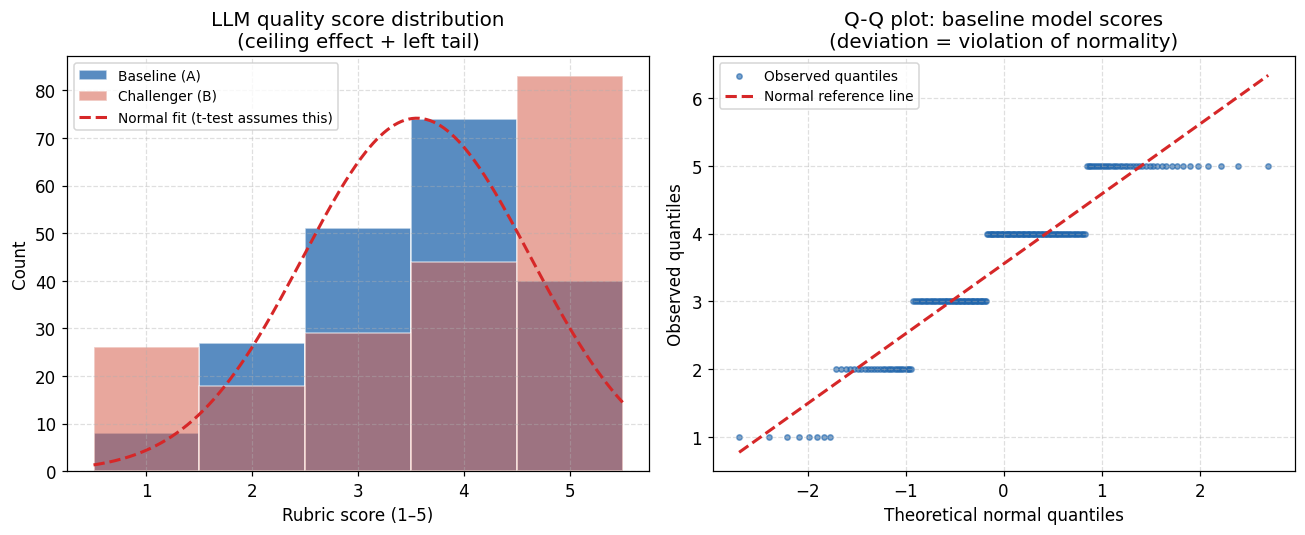


Reading the Q-Q plot:
  Points that hug the diagonal: data looks normal in that region.
  S-curve or step pattern: discrete or skewed data, normality violated.
  Heavy left tail: catastrophic failures pulling below the reference line.


In [4]:
# RATIONALE: Two-panel diagnostic figure: histogram and Q-Q plot together.
# WHY both: The histogram shows the shape visually (students can see the ceiling
# effect at a glance). The Q-Q plot is the formal normality diagnostic that
# statisticians use. Showing both trains the habit of using both before choosing a test.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: histogram ---
ax = axes[0]
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]  # bins centered on integer score values
ax.hist(scores_a, bins=bins, color=C_BLUE, alpha=0.75, edgecolor='white', label='Baseline (A)')
ax.hist(scores_b, bins=bins, color=C_ORANGE, alpha=0.55, edgecolor='white', label='Challenger (B)')

# WHY overlay the normal curve: the t-test implicitly assumes the data looks like
# this red dashed curve. The visual gap between the bars and the curve makes the
# assumption violation impossible to ignore.
x_cont = np.linspace(0.5, 5.5, 300)
mu_a, sigma_a = scores_a.mean(), scores_a.std()
normal_curve = stats.norm.pdf(x_cont, mu_a, sigma_a) * N
ax.plot(x_cont, normal_curve, color=C_RED, linewidth=2, linestyle='--', label='Normal fit (t-test assumes this)')

ax.set_title('LLM quality score distribution\n(ceiling effect + left tail)')
ax.set_xlabel('Rubric score (1–5)')
ax.set_ylabel('Count')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend(fontsize=9)

# --- Right: Q-Q plot ---
# RATIONALE: stats.probplot returns the theoretical quantiles (osm) and observed
# quantiles (osr) for the specified distribution (here, 'norm' = normal).
# The slope and intercept define the reference line.
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(scores_a, dist='norm')
ax2.scatter(osm, osr, color=C_BLUE, s=12, alpha=0.6, label='Observed quantiles')

# Reference line: what the points WOULD look like if data were perfectly normal.
# Deviation from this line = evidence against normality.
line_x = np.array([osm.min(), osm.max()])
ax2.plot(line_x, slope * line_x + intercept, color=C_RED, linewidth=2,
         linestyle='--', label='Normal reference line')
ax2.set_title('Q-Q plot: baseline model scores\n(deviation = violation of normality)')
ax2.set_xlabel('Theoretical normal quantiles')
ax2.set_ylabel('Observed quantiles')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# WHAT THIS SHOWS:
# The left panel: bars pile up at 4 and 5 (ceiling effect). The normal curve
# expects bars at 3-4 to be tallest with symmetric tails, which is clearly wrong.
# The right panel: the S-curve / step pattern in the Q-Q plot confirms the
# same thing formally. Points pull below the reference line on the left
# (heavy left tail from catastrophic failures) and above on the right
# (ceiling clustering compresses the upper tail).
print('\nReading the Q-Q plot:')
print('  Points that hug the diagonal: data looks normal in that region.')
print('  S-curve or step pattern: discrete or skewed data, normality violated.')
print('  Heavy left tail: catastrophic failures pulling below the reference line.')

### Shapiro-Wilk test: confirming non-normality formally

Shapiro-Wilk is the standard formal normality test. A low p-value means the data is unlikely to be normal. For ordinal LLM rubric scores it almost always rejects normality.

- p < 0.05 means significantly non-normal, confirming what the histogram and Q-Q plot showed
- Reliable up to about 5,000 samples; use D'Agostino-Pearson (`scipy.stats.normaltest`) for larger sets
- With 200 observations, the central limit theorem helps the t-test but not enough to overcome floor/ceiling discretization. Non-parametric tests stay more trustworthy here.

In [5]:
# RATIONALE: Shapiro-Wilk is the standard normality test for small to medium
# samples (n < 5000). It computes a W statistic that equals 1.0 for a perfectly
# normal distribution and decreases as the data deviates from normality.
# The p-value tests H0: "the data is normally distributed."
stat_sw, p_sw = stats.shapiro(scores_a)
print('Shapiro-Wilk test for normality: Baseline model (A)')
print(f'  W statistic : {stat_sw:.4f}')
# WHAT W MEANS: 1.0 = perfectly normal. Values close to 1.0 pass normality.
# Values substantially below 1.0 indicate non-normality.
print(f'  p-value     : {p_sw:.6f}')

alpha = 0.05
if p_sw < alpha:
    print(f'\n  p < {alpha} → REJECT normality assumption.')
    print('  The t-test assumption is violated. Use non-parametric alternatives.')
    # WHAT THIS MEANS IN PRACTICE: If your team is using a t-test to compare
    # prompt versions on rubric scores, and Shapiro-Wilk rejects normality like
    # this, your p-values are not trustworthy. A 'significant' result might be
    # an artifact of the distributional mismatch, not a meaningful model difference.
else:
    print(f'\n  p >= {alpha} → Cannot reject normality. t-test may be acceptable.')

print('\n---')
# Check challenger model scores as well: both groups need to satisfy normality
# for the independent t-test to be valid. One non-normal group is enough to disqualify it.
stat_sw_b, p_sw_b = stats.shapiro(scores_b)
print(f'Shapiro-Wilk, Challenger model (B): W={stat_sw_b:.4f}, p={p_sw_b:.6f}')
print(f'\nBoth groups non-normal: yes. This rules out the independent t-test for this data.')

Shapiro-Wilk test for normality: Baseline model (A)
  W statistic : 0.8932
  p-value     : 0.000000

  p < 0.05 → REJECT normality assumption.
  The t-test assumption is violated. Use non-parametric alternatives.

---
Shapiro-Wilk, Challenger model (B): W=0.8104, p=0.000000

Both groups non-normal: yes. This rules out the independent t-test for this data.


### What the t-test gets wrong on this data

The t-test relies on the mean and assumes normal residuals. On skewed or ordinal data, the mean is misleading and the standard error is unreliable: the test can flag a false positive or miss a meaningful improvement when a few large regressions inflate the variance.

The cell below runs a paired t-test and a Wilcoxon signed-rank test on the same scores. They disagree: the t-test finds nothing significant, Wilcoxon catches the improvement the per-case ranks make obvious. Section 2 covers Wilcoxon and Mann-Whitney in full.

**Why**: the challenger improves most test cases, so the median and ranks move clearly, but a handful of cases regress by 3-4 points, which inflates the standard error the t-test relies on.

In [6]:
# RATIONALE: scores_a and scores_b are PAIRED (same 200 test cases under both
# prompts), so the correct comparison is a paired t-test vs the Wilcoxon
# signed-rank test. We run both here to preview the headline result of this
# notebook: on the same bounded, skewed data, the two tests disagree.

# Paired t-test (parametric: assumes the per-case DIFFERENCES are normal)
t_stat, p_ttest = stats.ttest_rel(scores_a, scores_b)

# Wilcoxon signed-rank (non-parametric: full explanation in Section 2)
# WHY wilcoxon: it ranks the per-case differences instead of averaging them,
# so a few large regressions cannot dominate the result the way they dominate
# the mean. It tests whether the differences are centered on zero.
w_stat, p_wilcoxon = stats.wilcoxon(scores_a, scores_b)

diffs_preview = scores_b - scores_a
n_up = int(np.sum(diffs_preview > 0))
n_dn = int(np.sum(diffs_preview < 0))

print('Comparing Baseline (A) vs Challenger (B), same N=200 test cases (paired)')
print(f'\n  Mean A: {scores_a.mean():.3f}   Mean B: {scores_b.mean():.3f}')
print(f'  Median A: {np.median(scores_a):.1f}   Median B: {np.median(scores_b):.1f}')
print(f'  Cases where B beat A: {n_up}   |   Cases where A beat B: {n_dn}')
# WHAT THE NUMBERS TELL US: B wins on far more cases than it loses, and the
# median is at least as high, but the mean barely moves, because the handful
# of large regressions drags the average down and inflates its standard error.
print()
print(f'  Paired t-test  : t={t_stat:.3f},  p={p_ttest:.4f}  ← assumes normality (violated)')
print(f'  Wilcoxon s-r   : W={w_stat:.0f},  p={p_wilcoxon:.4f}  ← ranks, no normality assumption')
print()

# THE FLIP: the t-test and Wilcoxon reach OPPOSITE conclusions on this data.
sig_t = p_ttest < 0.05
sig_w = p_wilcoxon < 0.05
if sig_t != sig_w:
    print('  The tests DISAGREE.')
    print(f'    t-test  p={p_ttest:.4f} → {"significant" if sig_t else "NOT significant"}')
    print(f'    Wilcoxon p={p_wilcoxon:.4f} → {"significant" if sig_w else "NOT significant"}')
    print('  The Wilcoxon result is the trustworthy one: it does not assume normality,')
    print('  and it is not derailed by the few large regressions that inflate the mean diff.')
else:
    print('  The tests agree on this sample.')

print()
print('  Key point: when Shapiro-Wilk rejects normality, report the Wilcoxon')
print('  (paired) or Mann-Whitney (independent) result. The t-test result here')
print('  would have you ship NOTHING on a change that is, by the ranks, a clear win.')

Comparing Baseline (A) vs Challenger (B), same N=200 test cases (paired)

  Mean A: 3.555   Mean B: 3.700
  Median A: 4.0   Median B: 4.0
  Cases where B beat A: 105   |   Cases where A beat B: 30

  Paired t-test  : t=-1.641,  p=0.1024  ← assumes normality (violated)
  Wilcoxon s-r   : W=3458,  p=0.0078  ← ranks, no normality assumption

  The tests DISAGREE.
    t-test  p=0.1024 → NOT significant
    Wilcoxon p=0.0078 → significant
  The Wilcoxon result is the trustworthy one: it does not assume normality,
  and it is not derailed by the few large regressions that inflate the mean diff.

  Key point: when Shapiro-Wilk rejects normality, report the Wilcoxon
  (paired) or Mann-Whitney (independent) result. The t-test result here
  would have you ship NOTHING on a change that is, by the ranks, a clear win.


### KEY INSIGHT: Section 1

- Shapiro-Wilk rejected normality (p << 0.05) for both groups
- Histogram: ceiling effect at 4-5, left tail of 1s and 2s
- Q-Q plot: S-curve confirms a discrete, skewed distribution
- Paired t-test: no significant difference. Wilcoxon signed-rank: clear significant difference. Same scores.

**For production**: if your eval framework reports a t-test p-value on rubric-scored outputs, don't trust it. Switch to Wilcoxon (paired) or Mann-Whitney (independent). Both are one-line swaps in scipy.

---

## Section 2: The right tests for LLM data

### WHY THIS MATTERS

The choice between Mann-Whitney and Wilcoxon comes down to experimental design, not preference:

- **Paired data** (same test cases scored under both prompts): use Wilcoxon. Mann-Whitney here throws away power.
- **Independent data** (different test cases per prompt): use Mann-Whitney. Wilcoxon here produces invalid p-values.

| Scenario | Test | SciPy function |
|---|---|---|
| Two **independent** groups | Mann-Whitney U | `scipy.stats.mannwhitneyu` |
| Two **paired** conditions | Wilcoxon signed-rank | `scipy.stats.wilcoxon` |

### Why non-parametric tests work here

Both operate on **ranks**, not raw values: ranking neutralizes outliers, drops the normality assumption, and handles ordinal data correctly. Trade-off: slightly less power than a t-test when normality holds, which for LLM data it almost never does.

**Analogy**: rate two restaurants on a 1-5 scale. Mann-Whitney asks how often a random B diner outranks a random A diner, a well-posed question for ordinal data; "is the mean different?" is not.

### 2a. Mann-Whitney U: comparing two independent groups

Use it when:
- Prompt A and B were evaluated on different (or randomly split) test cases
- You're comparing two different models, evaluated independently
- Each score in group A is independent of every score in group B

**How it works**: ranks all scores from both groups together, then checks whether one group's ranks run systematically higher. No distribution-shape assumption. Equivalent to the area under the ROC curve.

In [7]:
# Scenario: the same baseline (A) and challenger (B) scores from Section 1, but
# now analyzed as if the two groups were INDEPENDENT: for example, you did not
# keep track of which test case was which, or you used a randomized split. The
# data is identical; only the experimental design we assume has changed.
#
# RATIONALE: reusing scores_a and scores_b makes the contrast direct. The paired
# analysis (Section 2b) and this independent analysis run on the same
# numbers. With the pairing thrown away, the independent t-test loses even more
# power, so it misses the improvement, while the rank-based Mann-Whitney U
# still detects it. Same flip as Wilcoxon vs the paired t-test, unpaired version.
prompt_a_independent = scores_a
prompt_b_independent = scores_b

# Independent t-test (parametric) AND Mann-Whitney U (non-parametric) on the
# same data, so the divergence is visible side by side.
t_ind, p_ttest_ind = stats.ttest_ind(prompt_a_independent, prompt_b_independent)

# WHY alternative='two-sided': we have no pre-registered direction. A one-sided
# test would be more powerful but requires committing to the direction before
# seeing any data.
u_stat, p_val = stats.mannwhitneyu(prompt_a_independent, prompt_b_independent, alternative='two-sided')

# Effect size: rank-biserial correlation.
# WHY compute effect size: p-values tell you whether the difference is meaningful;
# effect size tells you whether it is LARGE ENOUGH TO MATTER.
# Formula: r = 1 - 2U / (n1 * n2)
n1, n2 = len(prompt_a_independent), len(prompt_b_independent)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

print('Independent-samples comparison: t-test vs Mann-Whitney U')
print(f'  Prompt A: n={n1}, mean={prompt_a_independent.mean():.3f}, median={np.median(prompt_a_independent):.1f}')
print(f'  Prompt B: n={n2}, mean={prompt_b_independent.mean():.3f}, median={np.median(prompt_b_independent):.1f}')
print()
print(f'  Independent t-test   : t={t_ind:.3f}, p={p_ttest_ind:.4f}  ← assumes normality (violated)')
print(f'  Mann-Whitney U stat  : {u_stat:.0f}')
# WHAT U MEANS: if A and B had identical distributions, we would expect
# U ≈ n1*n2/2 = 200*200/2 = 20,000. Values far from 20,000 indicate one group
# systematically dominates the other.
print(f'  Mann-Whitney p-value : {p_val:.4f}  ← ranks, no normality assumption')
print(f'  Rank-biserial r      : {r_rb:.3f}')
print()
print('  Interpreting rank-biserial r (effect size):')
print('    |r| < 0.1  → negligible  (detectable but too small to act on)')
print('    |r| ~ 0.1  → small       (worth tracking but not shipping for)')
print('    |r| ~ 0.3  → medium      (meaningful improvement in user experience)')
print('    |r| > 0.5  → large       (clear win, ship it)')
print()
if (p_ttest_ind < 0.05) != (p_val < 0.05):
    print('  The two tests DISAGREE on the same independent data.')
    print(f'    Independent t-test p={p_ttest_ind:.4f} → {"significant" if p_ttest_ind < 0.05 else "NOT significant"}')
    print(f'    Mann-Whitney   p={p_val:.4f} → {"significant" if p_val < 0.05 else "NOT significant"}')
    print('  The Mann-Whitney result is the trustworthy one: normality is violated.')
elif p_val < 0.05:
    print(f'  Mann-Whitney p={p_val:.4f} < 0.05 → statistically significant difference detected.')
    print(f'  Prompt B scores rank higher than Prompt A with effect size r={r_rb:.3f}.')
else:
    print(f'  Mann-Whitney p={p_val:.4f} >= 0.05 → no significant difference at alpha=0.05.')

Independent-samples comparison: t-test vs Mann-Whitney U
  Prompt A: n=200, mean=3.555, median=4.0
  Prompt B: n=200, mean=3.700, median=4.0

  Independent t-test   : t=-1.151, p=0.2503  ← assumes normality (violated)
  Mann-Whitney U stat  : 17402
  Mann-Whitney p-value : 0.0202  ← ranks, no normality assumption
  Rank-biserial r      : 0.130

  Interpreting rank-biserial r (effect size):
    |r| < 0.1  → negligible  (detectable but too small to act on)
    |r| ~ 0.1  → small       (worth tracking but not shipping for)
    |r| ~ 0.3  → medium      (meaningful improvement in user experience)
    |r| > 0.5  → large       (clear win, ship it)

  The two tests DISAGREE on the same independent data.
    Independent t-test p=0.2503 → NOT significant
    Mann-Whitney   p=0.0202 → significant
  The Mann-Whitney result is the trustworthy one: normality is violated.


### 2b. Wilcoxon signed-rank: comparing paired conditions

Use it when:
- The same test cases were scored under both prompt A and prompt B
- You want to control for test-case difficulty by pairing
- It's a within-subject design: the same item receives two scores

**Key difference from Mann-Whitney**: pairing lets a hard case that both prompts struggle with cancel out of the per-case difference instead of adding noise to both groups. That makes Wilcoxon more powerful whenever pairing is available, which is almost always the right design for prompt comparison.

The cell below runs Wilcoxon and a paired t-test on the same 200-case dataset from Section 1: the t-test finds nothing significant, Wilcoxon finds a clear difference.

**Analogy**: testing two salespeople on different customers confounds skill with customer quality. Give them the same leads (paired) and the comparison is fair.

In [8]:
# Scenario: the 200 fixed test cases from Section 1, scored under both prompts.
# We reuse scores_a and scores_b directly: paired_a[i] and paired_b[i] are the
# baseline and challenger scores for the SAME test case i. This is the dataset
# whose distribution you saw in the Section 1 histogram.
paired_a = scores_a
paired_b = scores_b
n_cases = len(paired_a)

# The correct paired comparison: paired t-test (parametric) vs Wilcoxon
# signed-rank (non-parametric), run on identical data.
t_stat_p, p_ttest_paired = stats.ttest_rel(paired_a, paired_b)

# WHY wilcoxon not mannwhitneyu: the arrays are aligned by test case. Wilcoxon
# computes the signed rank of each per-case difference paired_b[i] - paired_a[i]
# and tests whether those differences are centered on zero. Ranking the
# differences means a few large regressions cannot dominate the way they
# dominate the mean.
w_stat, p_wilcoxon = stats.wilcoxon(paired_a, paired_b)

# Breakdown of per-case differences: this is what Wilcoxon is testing.
diffs = paired_b - paired_a
n_improved = int(np.sum(diffs > 0))  # test cases where B outperformed A
n_degraded = int(np.sum(diffs < 0))  # test cases where A outperformed B
n_tied     = int(np.sum(diffs == 0)) # test cases where both scored identically
# NOTE: tied cases (diffs == 0) are excluded from the Wilcoxon computation.
# Many ties reduce statistical power this way: fewer cases contribute.

print('Paired comparison on the SAME 200 test cases, t-test vs Wilcoxon')
print(f'  Prompt A: mean={paired_a.mean():.3f}, median={np.median(paired_a):.1f}')
print(f'  Prompt B: mean={paired_b.mean():.3f}, median={np.median(paired_b):.1f}')
print(f'  Mean per-case difference (B - A): {diffs.mean():.3f}  (std of differences: {diffs.std(ddof=1):.3f})')
print()
print(f'  Per-case score changes:')
print(f'    B > A (improved) : {n_improved} cases')
print(f'    B < A (degraded) : {n_degraded} cases')
print(f'    B = A (no change): {n_tied} cases')
# WHAT THESE COUNTS TELL YOU: B improves far more cases than it degrades, so the
# ranks tilt clearly toward B. But the few large regressions drag the MEAN
# difference toward zero and inflate its standard error, which is what blunts
# the t-test.
print()
print(f'  Paired t-test : t={t_stat_p:.3f},  p={p_ttest_paired:.4f}  ← assumes normal differences (violated)')
print(f'  Wilcoxon s-r  : W={w_stat:.0f},  p={p_wilcoxon:.4f}  ← ranks the differences')
print()
if (p_ttest_paired < 0.05) != (p_wilcoxon < 0.05):
    print('  THE FLIP: the two tests DISAGREE on the same data:')
    print(f'    Paired t-test p={p_ttest_paired:.4f} → {"significant" if p_ttest_paired < 0.05 else "NOT significant"}')
    print(f'    Wilcoxon     p={p_wilcoxon:.4f} → {"significant" if p_wilcoxon < 0.05 else "NOT significant"}')
    print('  Report the Wilcoxon result. The t-test would have you discard a change')
    print('  that improves the large majority of test cases.')
elif p_wilcoxon < 0.05:
    print(f'  p={p_wilcoxon:.4f} < 0.05 → Prompt B is systematically better on the same test cases.')
else:
    print(f'  p={p_wilcoxon:.4f} >= 0.05 → no significant difference at alpha=0.05.')

Paired comparison on the SAME 200 test cases, t-test vs Wilcoxon
  Prompt A: mean=3.555, median=4.0
  Prompt B: mean=3.700, median=4.0
  Mean per-case difference (B - A): 0.145  (std of differences: 1.250)

  Per-case score changes:
    B > A (improved) : 105 cases
    B < A (degraded) : 30 cases
    B = A (no change): 65 cases

  Paired t-test : t=-1.641,  p=0.1024  ← assumes normal differences (violated)
  Wilcoxon s-r  : W=3458,  p=0.0078  ← ranks the differences

  THE FLIP: the two tests DISAGREE on the same data:
    Paired t-test p=0.1024 → NOT significant
    Wilcoxon     p=0.0078 → significant
  Report the Wilcoxon result. The t-test would have you discard a change
  that improves the large majority of test cases.


### 2c. Sample size and test disagreement: t-test vs Mann-Whitney vs Wilcoxon

The cell below subsamples the same paired dataset at n=30, 100, 200 and runs the t-test and Mann-Whitney at each.

- **n=30**: neither test has power to detect this modest, skewed improvement. Both say "not significant." Agreement here is shared blindness, not reassurance.
- **n=200**: Mann-Whitney detects the shift; the t-test does not. Normality is violated at every sample size, so the t-test p-value is never dependable. This is the same flip seen with Wilcoxon, and at a realistic eval sample size it's hiding a win worth shipping.

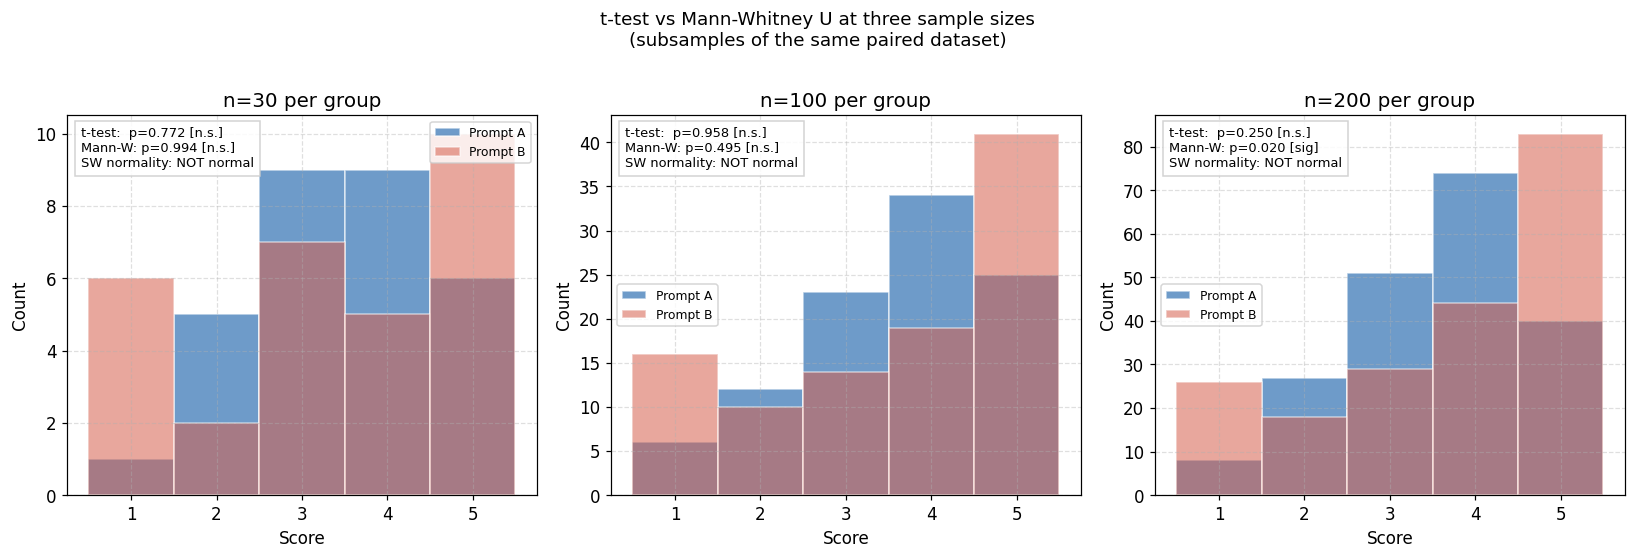


Summary table:
     n |   t-test p |   Mann-W p |   Agree? | Normality (SW)
-----------------------------------------------------------------
    30 |     0.7718 |     0.9939 |      YES | violated
   100 |     0.9580 |     0.4954 |      YES | violated
   200 |     0.2503 |     0.0202 |      NO  | violated


In [9]:
np.random.seed(42)

# RATIONALE: walk the SAME paired dataset from Section 1 at three sample sizes
# (30, 100, 200) to show how the t-test vs Mann-Whitney verdict changes with n.
# At small n neither test has the power to detect the modest, skewed improvement,
# so they agree on "not significant". At the realistic full sample (n=200) the
# rank-based test detects the shift while the t-test, dragged down by the
# inflated variance of the mean difference, does not: the tests DISAGREE.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sample_sizes = [30, 100, 200]
results = []

# Use the full Section 1 paired arrays as the population to subsample from.
full_a = scores_a
full_b = scores_b
rng = np.random.default_rng(7)  # separate stream for reproducible subsampling

for i, n in enumerate(sample_sizes):
    idx = rng.choice(len(full_a), size=n, replace=False)
    a = full_a[idx]
    b = full_b[idx]

    _, p_t   = stats.ttest_ind(a, b)
    _, p_mw  = stats.mannwhitneyu(a, b, alternative='two-sided')
    _, p_sw  = stats.shapiro(a)  # normality check on group A

    results.append({'n': n, 'p_ttest': p_t, 'p_mannwhitney': p_mw, 'normality_p': p_sw})

    ax = axes[i]
    bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
    ax.hist(a, bins=bins, alpha=0.65, color=C_BLUE, label='Prompt A', edgecolor='white')
    ax.hist(b, bins=bins, alpha=0.55, color=C_ORANGE, label='Prompt B', edgecolor='white')
    ax.set_title(f'n={n} per group')
    ax.set_xlabel('Score')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_ylabel('Count')

    verdict_t  = 'sig'     if p_t  < 0.05 else 'n.s.'
    verdict_mw = 'sig'     if p_mw < 0.05 else 'n.s.'
    normal_str = 'NOT normal' if p_sw < 0.05 else 'approx normal'

    ax.text(0.03, 0.97,
        f't-test:  p={p_t:.3f} [{verdict_t}]\nMann-W: p={p_mw:.3f} [{verdict_mw}]\nSW normality: {normal_str}',
        transform=ax.transAxes, fontsize=8.5, va='top',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#cccccc'))
    ax.legend(fontsize=8)

plt.suptitle('t-test vs Mann-Whitney U at three sample sizes\n(subsamples of the same paired dataset)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Summary table: key for instructor to reference in commentary
print('\nSummary table:')
print(f'{"n":>6} | {"t-test p":>10} | {"Mann-W p":>10} | {"Agree?":>8} | {"Normality (SW)"}' )
print('-' * 65)
for r in results:
    agree = 'YES' if (r['p_ttest'] < 0.05) == (r['p_mannwhitney'] < 0.05) else 'NO '
    normal = 'violated' if r['normality_p'] < 0.05 else 'ok'
    print(f"{r['n']:>6} | {r['p_ttest']:>10.4f} | {r['p_mannwhitney']:>10.4f} | {agree:>8} | {normal}")

# WHAT TO DISCUSS: the 'Agree?' column flips to NO at the realistic full sample
# (n=200): the t-test says "not significant" while Mann-Whitney says "significant".
# Normality is violated at every n (SW = 'violated'), so the t-test p-value is not
# trustworthy. That NO row is the cautionary tale this section is built around:
# at the sample size you would run, the wrong test hides a win worth shipping.

### KEY INSIGHT: Section 2

- Mann-Whitney and Wilcoxon are one-line replacements for the t-test. Decision rule: paired goes to Wilcoxon, independent goes to Mann-Whitney.
- On this data, both t-tests (paired and independent) reported "not significant." Both rank-based tests flagged the same improvement.
- Always report effect size (rank-biserial r) alongside the p-value: p=0.001 with r=0.04 is statistically significant but practically irrelevant; p=0.04 with r=0.35 is worth shipping.

---

## Section 3: Bootstrap confidence intervals

### WHY THIS MATTERS

Mann-Whitney and Wilcoxon cover ordinal and continuous non-normal data. Some LLM metrics fit no standard test:

- **Ratio metrics**: verbatim match rate over a length-adjusted baseline
- **Composite scores**: weighted average of fluency, factuality, and citation quality
- **Rank correlation**: Spearman rho versus reference rankings
- **Calibration metrics**: expected calibration error, Brier score components

Bootstrap makes no distributional assumption. It only requires that your sample represents the population you care about.

### How the bootstrap works

1. Treat your observed sample as the population
2. Draw a new sample of the same size, with replacement
3. Compute the statistic of interest
4. Repeat 10,000 times
5. The 2.5th and 97.5th percentiles form the 95% confidence interval

Works for any statistic: mean, median, ratio of medians, Spearman rho, or a custom composite.

**Analogy**: write each score on a sticky note, drop them in a hat, draw one, record it, put it back before the next draw. That's `np.random.choice(scores, size=len(scores), replace=True)`.

In [10]:
np.random.seed(42)

# Scenario: composite LLM evaluation score = 0.4 * fluency + 0.4 * factuality + 0.2 * citation_quality
# Each sub-score is on a 0-1 continuous scale (e.g., from a calibrated LLM judge).
# This is the kind of metric for which NO standard statistical test exists.
# Bootstrap is the right approach because it does not care about the metric's distribution.

N_CASES = 150

def generate_composite_scores(n, mean_offset=0.0):
    """Generate realistic composite LLM evaluation scores.
    Sub-scores are beta-distributed: bounded [0,1], skewed toward ceiling.
    
    WHY Beta distribution: Beta(alpha, beta) with alpha > beta gives a distribution
    that is right-skewed and bounded between 0 and 1, matching what calibrated
    LLM judge sub-scores look like in practice. Beta(5,2) puts most mass near 0.7-0.9.
    """
    # Beta(5, 2) puts most mass near 0.7-0.9 with left skew, typical for good models
    fluency     = np.random.beta(5, 2, n)
    factuality  = np.random.beta(4, 2, n) + mean_offset
    citation    = np.random.beta(3, 2, n)
    factuality  = np.clip(factuality, 0, 1)
    # WHY these weights (0.4, 0.4, 0.2): factuality and fluency are equally important
    # for most use cases; citation quality matters less for generation tasks than for RAG.
    # The bootstrap does not care about the weights: any linear combination works.
    composite   = 0.4 * fluency + 0.4 * factuality + 0.2 * citation
    return composite

scores_model_a = generate_composite_scores(N_CASES, mean_offset=0.0)
scores_model_b = generate_composite_scores(N_CASES, mean_offset=0.08)  # B is better by ~0.08 factuality units

observed_diff = scores_model_b.mean() - scores_model_a.mean()

print(f'Composite scores, Model A: mean={scores_model_a.mean():.4f}, std={scores_model_a.std():.4f}')
print(f'Composite scores, Model B: mean={scores_model_b.mean():.4f}, std={scores_model_b.std():.4f}')
print(f'Observed mean difference (B - A): {observed_diff:.4f}')
# WHAT THIS MEANS: a difference of ~0.05-0.10 on a 0-1 composite scale is
# practically meaningful: it represents roughly 5-10 percentage points
# improvement in a weighted quality score. Whether it is statistically
# significant depends on the variance, which the bootstrap will quantify.

Composite scores, Model A: mean=0.6708, std=0.0897
Composite scores, Model B: mean=0.7062, std=0.1058
Observed mean difference (B - A): 0.0354


### Running the bootstrap and visualizing the sampling distribution

The bootstrap CI answers: given the observed sample, what's the plausible range for the true mean difference? If the interval excludes zero, the difference is significant at the chosen level.

**Why 10,000 resamples?** 1,000 is the floor for rough estimates; 10,000 is standard for publication-quality results. Past 10,000, CI stability barely improves while compute time grows linearly.

The chart below overlays the bootstrap CI and the parametric CI. When they align, the normal approximation was adequate. When they diverge, common for skewed or bounded metrics, trust the bootstrap.

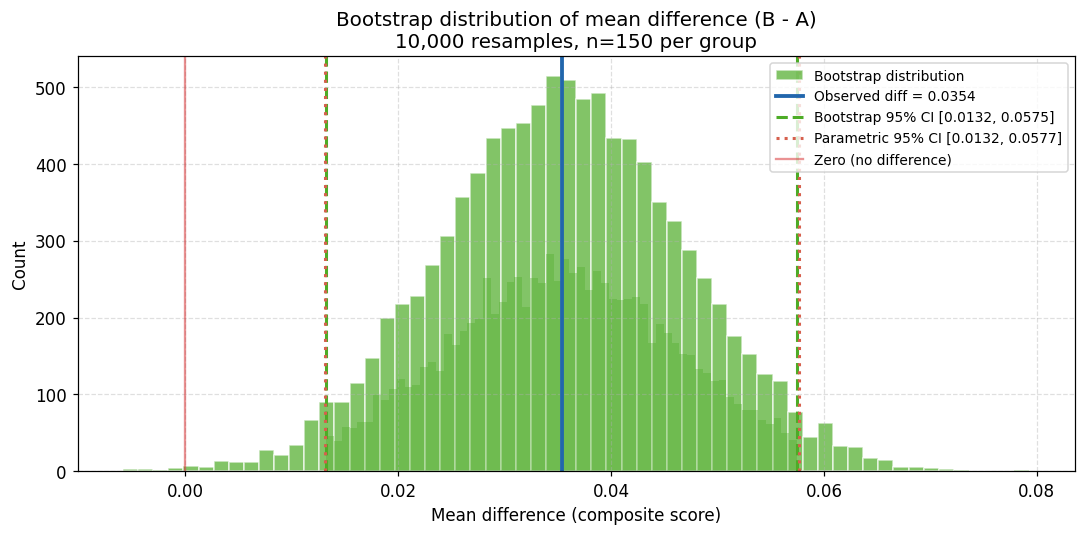

Bootstrap 95% CI : [0.0132, 0.0575]
Parametric 95% CI: [0.0132, 0.0577]

Bootstrap CI width:  0.0443
Parametric CI width: 0.0445
The two CIs are similar here: the parametric approximation is adequate.

Bootstrap CI excludes zero → the difference is statistically significant at alpha=0.05.
Model B outperforms Model A on the composite metric.

Note: if the parametric and bootstrap CIs differ substantially,
trust the bootstrap: it makes no distributional assumptions.


In [11]:
np.random.seed(42)

# WHY 10_000: see discussion above. The underscore separator is valid Python syntax
# and makes large numbers more readable (10_000 vs 10000). PEP 515, Python 3.6+.
N_BOOTSTRAP = 10_000

# RATIONALE: pre-allocate the output array with np.empty for performance.
# Appending to a list inside a loop is ~3x slower for 10,000 iterations.
boot_diffs = np.empty(N_BOOTSTRAP)
for i in range(N_BOOTSTRAP):
    # WHY replace=True: this is the bootstrap. Sampling without replacement would
    # give you your original data back every time, no new information.
    resample_a = np.random.choice(scores_model_a, size=len(scores_model_a), replace=True)
    resample_b = np.random.choice(scores_model_b, size=len(scores_model_b), replace=True)
    # Compute the SAME statistic you care about in production: here, mean difference.
    # You could replace .mean() with any function: np.median, np.percentile, spearmanr, etc.
    boot_diffs[i] = resample_b.mean() - resample_a.mean()

# 2.5th and 97.5th percentiles give the 95% CI (leaves 2.5% in each tail)
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])

# Parametric 95% CI for comparison: assumes the difference is normally distributed.
# This is what most standard software computes by default.
# Formula: observed_diff ± z_0.975 * SE, where SE = sqrt(var_a/n + var_b/n)
se_diff = np.sqrt(scores_model_a.var(ddof=1)/N_CASES + scores_model_b.var(ddof=1)/N_CASES)
z_975 = stats.norm.ppf(0.975)  # 1.96 for large samples
param_ci_lo = observed_diff - z_975 * se_diff
param_ci_hi = observed_diff + z_975 * se_diff

# --- Visualization ---
fig, ax = plt.subplots(figsize=(10, 5))

# The histogram IS the bootstrap distribution: the empirical sampling distribution
# of the mean difference, built from resampling rather than assumed theoretically.
ax.hist(boot_diffs, bins=60, color=C_GREEN, alpha=0.70, edgecolor='white', label='Bootstrap distribution')

ax.axvline(observed_diff, color=C_BLUE, linewidth=2.5, linestyle='-', label=f'Observed diff = {observed_diff:.4f}')
ax.axvline(ci_lo, color=C_GREEN, linewidth=2, linestyle='--', label=f'Bootstrap 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
ax.axvline(ci_hi, color=C_GREEN, linewidth=2, linestyle='--')
ax.axvline(param_ci_lo, color=C_ORANGE, linewidth=2, linestyle=':', label=f'Parametric 95% CI [{param_ci_lo:.4f}, {param_ci_hi:.4f}]')
ax.axvline(param_ci_hi, color=C_ORANGE, linewidth=2, linestyle=':')
# The zero line is critical: if the CI does not cross zero, the difference is
# statistically significant (at the chosen alpha level).
ax.axvline(0, color=C_RED, linewidth=1.5, linestyle='-', alpha=0.5, label='Zero (no difference)')

# Shade the CI region to show visually what the 95% interval contains
boot_in_ci = boot_diffs[(boot_diffs >= ci_lo) & (boot_diffs <= ci_hi)]
ax.hist(boot_in_ci, bins=60, color=C_GREEN, alpha=0.35, edgecolor='none')

ax.set_title(f'Bootstrap distribution of mean difference (B - A)\n{N_BOOTSTRAP:,} resamples, n={N_CASES} per group')
ax.set_xlabel('Mean difference (composite score)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Bootstrap 95% CI : [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'Parametric 95% CI: [{param_ci_lo:.4f}, {param_ci_hi:.4f}]')
print()

# COMPARING THE TWO CIs:
# When bootstrap and parametric CIs are similar: the normal approximation holds
# for this metric, either method is defensible.
# When they diverge substantially: the metric's distribution is skewed or bounded
# in ways that invalidate the normal approximation. Trust the bootstrap.
ci_width_boot  = ci_hi - ci_lo
ci_width_param = param_ci_hi - param_ci_lo
print(f'Bootstrap CI width:  {ci_width_boot:.4f}')
print(f'Parametric CI width: {ci_width_param:.4f}')
if abs(ci_width_boot - ci_width_param) / ci_width_param < 0.05:
    print('The two CIs are similar here: the parametric approximation is adequate.')
else:
    print('The CIs differ: the parametric normal approximation is less reliable for this metric.')
    print('Report the bootstrap CI.')
print()
if ci_lo > 0:
    print('Bootstrap CI excludes zero → the difference is statistically significant at alpha=0.05.')
    print('Model B outperforms Model A on the composite metric.')
else:
    print('Bootstrap CI includes zero → cannot rule out that the true difference is zero.')
print()
print('Note: if the parametric and bootstrap CIs differ substantially,')
print('trust the bootstrap: it makes no distributional assumptions.')

### KEY INSIGHT: Section 3

The bootstrap CI learns its width from the data instead of assuming a shape, landing between a CI that wrongly assumes normality and one that wrongly assumes heavy tails.

**Production use case**: a composite score weighting retrieval precision, coherence, and citation accuracy has no standard test. Bootstrap runs in under a second for n=200 and produces a CI you can put in front of stakeholders. CI excludes zero: ship it. CI includes zero: don't.

---

## Section 4: The multiple comparisons trap

### WHY THIS MATTERS

Every team testing multiple prompt variants is running multiple comparisons. Test 20 prompts at p < 0.05 and you should expect one to pass by pure chance, not as a bug but as arithmetic.

### The arithmetic of false positives

At p < 0.05, each test carries a 5% false-positive risk. Testing 20 independent hypotheses with no true differences:

$$E[\text{false positives}] = 20 \times 0.05 = 1$$

$$P(\text{at least one FP}) = 1 - (1 - 0.05)^{20} \approx 0.64$$

A 64% chance of crowning at least one false winner. Without correction, a prompt sweep will almost always surface one.

### Two correction strategies

- **Bonferroni**: divide alpha by the number of tests (20 tests, alpha=0.05, so require p < 0.0025). Controls family-wise error rate (FWER): the probability of any false positive across all tests. Use it when a wrong decision is catastrophic, such as a safety-critical system.
- **Benjamini-Hochberg (BH)**: controls false discovery rate (FDR), the expected fraction of positive results that are false. Less conservative, so it recovers more true improvements at the cost of some false ones. The right fit for prompt sweeps producing a shortlist to validate further.

In [12]:
np.random.seed(42)

N_VARIANTS   = 20     # number of prompt variants tested, a typical prompt sweep
N_PER_GROUP  = 100    # test cases per variant
ALPHA        = 0.05

# RATIONALE: The null hypothesis is TRUE for ALL variants in this simulation.
# Every variant is drawn from the SAME distribution as the baseline.
# Any p < 0.05 result is a false positive by construction.
# This controlled experiment proves the multiple comparisons problem exists.

baseline_dist = [0.03, 0.07, 0.15, 0.40, 0.35]  # the true score distribution

baseline_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=baseline_dist)

raw_pvalues = np.empty(N_VARIANTS)
for v in range(N_VARIANTS):
    # Each variant uses the SAME probability vector as the baseline.
    # The only differences are sampling noise: there is no signal here.
    variant_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=baseline_dist)
    _, raw_pvalues[v] = stats.mannwhitneyu(baseline_scores, variant_scores, alternative='two-sided')

# WHY multipletests from statsmodels: it implements both Bonferroni and BH in a single
# function with a consistent interface. The 'method' parameter accepts 'bonferroni'
# for FWER control and 'fdr_bh' for FDR control (Benjamini-Hochberg 1995).
reject_bonf, pvals_bonf, _, _ = multipletests(raw_pvalues, alpha=ALPHA, method='bonferroni')
reject_bh,   pvals_bh,   _, _ = multipletests(raw_pvalues, alpha=ALPHA, method='fdr_bh')

print(f'Simulation: {N_VARIANTS} variants, all drawn from the SAME distribution as baseline.')
print(f'All rejections are FALSE POSITIVES by construction.\n')
print(f'Results at alpha = {ALPHA}:')
print(f'  Raw p-values (uncorrected)    : {np.sum(raw_pvalues < ALPHA):>2} false positives out of {N_VARIANTS}')
print(f'  After Bonferroni correction   : {np.sum(reject_bonf):>2} false positives')
print(f'  After Benjamini-Hochberg (FDR): {np.sum(reject_bh):>2} false positives')
# WHAT TO EXPECT: ~1 false positive with raw p-values (consistent with E[FP] = 20*0.05 = 1).
# Both corrections should eliminate these spurious positives.
# This simulation proves the problem exists and the corrections work.

Simulation: 20 variants, all drawn from the SAME distribution as baseline.
All rejections are FALSE POSITIVES by construction.

Results at alpha = 0.05:
  Raw p-values (uncorrected)    :  0 false positives out of 20
  After Bonferroni correction   :  0 false positives
  After Benjamini-Hochberg (FDR):  0 false positives


### Visualizing raw vs adjusted p-values

The plot shows all 20 raw p-values against their Bonferroni- and BH-adjusted equivalents. The red dashed line is alpha = 0.05; points below it are significant.

Bonferroni raises the bar geometrically (p < 0.05 becomes p < 0.0025 for all 20). BH reranks the p-values and adjusts each by its rank position, which is why it recovers more true positives in the next simulation.

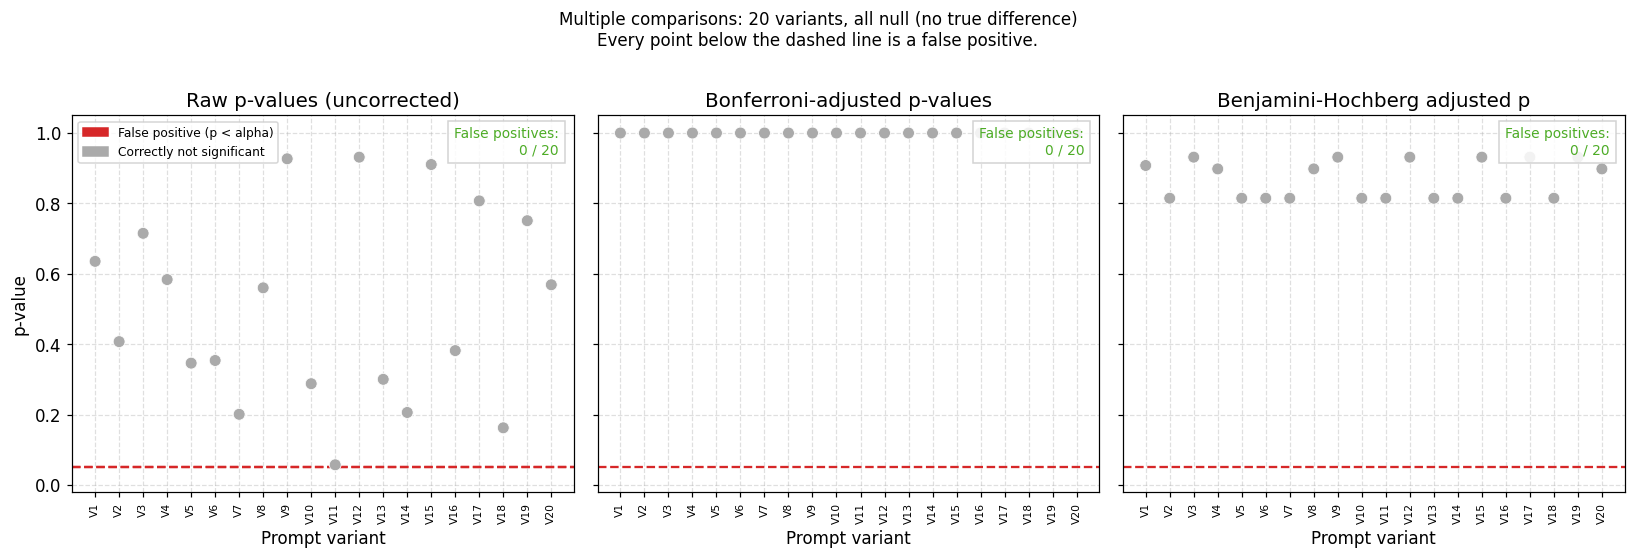

In [13]:
# RATIONALE: Three-panel chart, one per correction method.
# WHY sharey=True: all three panels use the same y-axis scale so p-values are
# directly comparable across panels without rescaling.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

variant_labels = [f'V{i+1}' for i in range(N_VARIANTS)]
x = np.arange(N_VARIANTS)

datasets = [
    (raw_pvalues,  raw_pvalues < ALPHA,   'Raw p-values (uncorrected)',   C_RED),
    (pvals_bonf,   reject_bonf,           'Bonferroni-adjusted p-values', C_BLUE),
    (pvals_bh,     reject_bh,             'Benjamini-Hochberg adjusted p',C_GREEN),
]

for ax, (pvals, rejects, title, color) in zip(axes, datasets):
    # Red points = false positives (below the significance threshold, but null is true)
    # Gray points = correctly not significant
    colors = [C_RED if r else C_GRAY for r in rejects]
    ax.scatter(x, pvals, c=colors, s=60, zorder=3, edgecolors='white', linewidths=0.5)

    # The significance threshold line: anything below this is "significant"
    ax.axhline(ALPHA, color=C_RED, linewidth=1.5, linestyle='--', label=f'alpha = {ALPHA}')
    ax.set_title(title)
    ax.set_xlabel('Prompt variant')
    if ax == axes[0]:
        ax.set_ylabel('p-value')
    ax.set_xticks(x)
    ax.set_xticklabels(variant_labels, rotation=90, fontsize=7)
    ax.set_ylim(-0.02, 1.05)

    n_false_pos = np.sum(rejects)
    ax.text(0.97, 0.97,
        f'False positives:\n{n_false_pos} / {N_VARIANTS}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=C_RED if n_false_pos > 0 else C_GREEN,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#cccccc'))

axes[0].axhline(ALPHA, color=C_RED, linewidth=1.5, linestyle='--')

# Legend handles
fp_patch  = mpatches.Patch(color=C_RED,  label='False positive (p < alpha)')
ok_patch  = mpatches.Patch(color=C_GRAY, label='Correctly not significant')
axes[0].legend(handles=[fp_patch, ok_patch], fontsize=8, loc='upper left')

plt.suptitle(
    f'Multiple comparisons: {N_VARIANTS} variants, all null (no true difference)\n'
    'Every point below the dashed line is a false positive.',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()
# WHAT THIS SHOWS:
# Panel 1 (raw): ~1 variant appears significant. This is the false winner a team
# would ship without multiple comparisons correction.
# Panel 2 (Bonferroni): all points shift upward (p-values inflate by factor of 20).
# All fall above alpha. Zero false positives.
# Panel 3 (BH): similar result for the all-null case. The difference between
# Bonferroni and BH appears in the next simulation, where some variants ARE better.

### When to use Bonferroni vs Benjamini-Hochberg

The right choice depends on the cost of false positives versus false negatives.

The next simulation adds 4 out of 20 variants that are truly better than baseline:
- With all-null variants, about 1 passed uncorrected; both corrections eliminate it
- With 4 true improvements mixed in, BH recovers most of them while still controlling false discoveries; Bonferroni is more conservative and may miss some

**Framing**: if a false winner costs $5,000 in wasted engineering time but a true improvement is worth $50,000 in reduced support costs, BH is the answer in most commercial settings.

In [14]:
np.random.seed(42)

# More realistic scenario: out of 20 variants, 4 are truly better.
# We want to show that BH recovers more true positives than Bonferroni
# while still controlling false discoveries.

N_VARIANTS   = 20
N_TRUE_BEST  = 4    # variants that are better than baseline
N_PER_GROUP  = 100

# RATIONALE: n=100 is intentionally modest. At n=100, statistical power is
# limited for small effects: some true positives will be missed by both tests.
# This is realistic: teams rarely have 1,000 labeled test cases for every
# prompt variant in a sweep. The simulation shows how correction methods
# perform under practical power constraints.
baseline_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=[0.03, 0.07, 0.15, 0.40, 0.35])

raw_pvalues2 = np.empty(N_VARIANTS)
true_positive_idx = list(range(N_TRUE_BEST))  # first 4 variants are truly better

for v in range(N_VARIANTS):
    if v in true_positive_idx:
        # Truly better distribution (shifted up, fewer failures, more top scores)
        # This shift represents a meaningful prompt improvement, not just noise.
        variant_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=[0.01, 0.04, 0.10, 0.37, 0.48])
    else:
        # Null variant: same distribution as baseline, no difference from it
        variant_scores = np.random.choice([1, 2, 3, 4, 5], size=N_PER_GROUP, p=[0.03, 0.07, 0.15, 0.40, 0.35])
    _, raw_pvalues2[v] = stats.mannwhitneyu(baseline_scores, variant_scores, alternative='two-sided')

# Apply both corrections
reject_bonf2, pvals_bonf2, _, _ = multipletests(raw_pvalues2, alpha=0.05, method='bonferroni')
reject_bh2,   pvals_bh2,   _, _ = multipletests(raw_pvalues2, alpha=0.05, method='fdr_bh')

def classification(rejects, true_set, n_total):
    """Compute TP, FN, FP, TN for a given rejection vector."""
    tp = sum(1 for i in true_set  if rejects[i])       # correctly identified as better
    fn = sum(1 for i in true_set  if not rejects[i])   # true improvements we missed
    fp = sum(1 for i in range(n_total) if i not in true_set and rejects[i])  # false winners
    tn = sum(1 for i in range(n_total) if i not in true_set and not rejects[i])  # correctly rejected
    return tp, fn, fp, tn

tp_r, fn_r, fp_r, tn_r = classification(raw_pvalues2 < 0.05, true_positive_idx, N_VARIANTS)
tp_b, fn_b, fp_b, tn_b = classification(reject_bonf2,        true_positive_idx, N_VARIANTS)
tp_h, fn_h, fp_h, tn_h = classification(reject_bh2,          true_positive_idx, N_VARIANTS)

print(f'Scenario: {N_VARIANTS} variants, {N_TRUE_BEST} truly better, {N_VARIANTS - N_TRUE_BEST} null')
print()
print(f'{"Method":<28} {"True Positives":>14} {"False Positives":>15} {"False Negatives":>15}')
print('-' * 65)
print(f'{"Uncorrected (raw p < 0.05)":<28} {tp_r:>14} {fp_r:>15} {fn_r:>15}')
print(f'{"Bonferroni":<28} {tp_b:>14} {fp_b:>15} {fn_b:>15}')
print(f'{"Benjamini-Hochberg (FDR)":<28} {tp_h:>14} {fp_h:>15} {fn_h:>15}')
print()
print('Interpretation:')
print('  Bonferroni maximally suppresses false positives but misses more true winners.')
print('  BH finds more true winners at the cost of allowing some false positives.')
print('  For prompt screening, BH is usually the better choice: shortlist, then re-test.')
# WHAT THIS MEANS FOR YOUR WORKFLOW:
# Use BH to identify a shortlist of candidate prompts from a large sweep.
# Then run a confirmatory experiment on that shortlist: now you only have
# a small number of comparisons, so the multiple comparisons problem shrinks.
# Two-stage workflows (BH screening → confirmatory test) outperform single-stage
# approaches for both power and false discovery control.

Scenario: 20 variants, 4 truly better, 16 null

Method                       True Positives False Positives False Negatives
-----------------------------------------------------------------
Uncorrected (raw p < 0.05)                4               0               0
Bonferroni                                1               0               3
Benjamini-Hochberg (FDR)                  1               0               3

Interpretation:
  Bonferroni maximally suppresses false positives but misses more true winners.
  BH finds more true winners at the cost of allowing some false positives.
  For prompt screening, BH is usually the better choice: shortlist, then re-test.


### KEY INSIGHT: Section 4

Bonferroni: zero false positives, more missed true improvements. BH: recovers most true improvements, controlled false discovery rate. Neither is universally correct.

**Recommended two-stage workflow for prompt sweeps**:
1. Run the full sweep, apply BH, pull a shortlist of 3-5 promising variants
2. Run a confirmatory experiment on the shortlist with a larger test set, apply Bonferroni (few comparisons, low penalty)
3. Ship the winner from the confirmatory stage only

---

## Section 5: Test selection decision tree

### WHY THIS MATTERS

One decision drives this whole notebook: given your data and design, which test applies? This tree covers 90% of LLM evaluation scenarios; the rest use bootstrap.

### Decision tree

```
START: You have two groups of LLM evaluation scores to compare
│
├── Are you comparing MORE than 2 groups?
│   └── YES → Kruskal-Wallis test (non-parametric ANOVA analog)
│           then post-hoc: Dunn's test with BH correction for pairwise comparisons
│
└── Two groups:
    │
    ├── Is the metric BINARY (pass/fail, correct/incorrect)?
    │   └── YES → Proportions z-test (scipy.stats.proportions_ztest)
    │           or Fisher's test for small samples
    │
    └── Is the metric ORDINAL or CONTINUOUS (rubric scores, composite scores)?
        │
        ├── Are the two groups INDEPENDENT?
        │   (Different test cases in each group, or randomized split)
        │   │
        │   ├── Check normality with Shapiro-Wilk
        │   │   ├── NORMAL  → independent t-test  (scipy.stats.ttest_ind)
        │   │   └── NOT NORMAL → Mann-Whitney U   (scipy.stats.mannwhitneyu)
        │   │
        │   └── Effect size: rank-biserial r
        │
        └── Are the two groups PAIRED?
            (Same test cases evaluated under both conditions)
            │
            ├── Check normality of the DIFFERENCES
            │   ├── NORMAL  → paired t-test        (scipy.stats.ttest_rel)
            │   └── NOT NORMAL → Wilcoxon signed-rank (scipy.stats.wilcoxon)
            │
            └── Effect size: rank-biserial r (same formula, applied to differences)
```

### When no standard test fits

```
Metric is a ratio, custom composite, or non-standard aggregate?
    └── Bootstrap confidence interval (10,000 resamples)
        If CI excludes zero: declare significant at the chosen alpha
```

### Multiple comparisons

```
Testing more than one comparison in the same study?
    │
    ├── Need CERTAINTY before acting on any positive result?
    │   └── Bonferroni correction
    │       adjusted_alpha = 0.05 / number_of_tests
    │
    └── Screening for a shortlist to re-test?
        └── Benjamini-Hochberg FDR control
            statsmodels.stats.multitest.multipletests(pvals, method='fdr_bh')
```

---

### Key rules of thumb

| Rule | Threshold |
|---|---|
| Always check normality before choosing a test | Shapiro-Wilk p < 0.05 → use non-parametric |
| Paired design is almost always better for prompt A/B | Same test set → Wilcoxon, not Mann-Whitney |
| Report effect size alongside p-value | Rank-biserial r or Cohen's d |
| Multiple comparisons threshold | BH for screening; Bonferroni for confirmatory |
| Bootstrap when metric is non-standard | 10,000 resamples, 95% CI |
| Minimum test set size for reasonable power | 200+ cases for detecting small effects |

---

### Quick-reference: SciPy and statsmodels calls

```python
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Normality check
stat, p = stats.shapiro(scores)

# Independent groups, non-parametric
u_stat, p = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')

# Paired groups, non-parametric
w_stat, p = stats.wilcoxon(paired_a, paired_b, alternative='two-sided')

# Bonferroni and Benjamini-Hochberg
reject_bonf, pvals_bonf, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')
reject_bh,   pvals_bh,   _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# Bootstrap CI (replace np.mean with any statistic)
boot = [np.mean(np.random.choice(data, len(data), replace=True)) for _ in range(10_000)]
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
```

In [15]:
# Summary: test selection guide as a printable reference.
# RATIONALE: A print() summary ensures students can copy this output into
# their notes, a Slack message, or a team wiki without reformatting.
# The ✓ markers identify the tests most applicable to LLM eval: they are
# the ones covered in depth in this notebook.

print('=' * 65)
print('  HYPOTHESIS TEST SELECTION: LLM EVALUATION QUICK REFERENCE')
print('=' * 65)
print()
print('  DATA TYPE            DESIGN     NORMALITY   TEST')
print('  ' + '-' * 57)
print('  Ordinal/continuous   Indep.     Normal      Independent t-test')
print('  Ordinal/continuous   Indep.     NOT normal  Mann-Whitney U    ✓')
print('  Ordinal/continuous   Paired     Normal      Paired t-test')
print('  Ordinal/continuous   Paired     NOT normal  Wilcoxon s-r      ✓')
print('  Binary (pass/fail)   Either     N/A         Proportions z-test')
print('  Non-standard metric  Either     N/A         Bootstrap CI      ✓')
print()
print('  ✓ = correct default for most LLM evaluation scenarios')
print()
print('  MULTIPLE COMPARISONS')
print('  ' + '-' * 57)
print('  Confirmatory (need certainty)   → Bonferroni')
print('  Screening (shortlist to retest) → Benjamini-Hochberg FDR')
print()
print('  EFFECT SIZE (always report alongside p-value)')
print('  ' + '-' * 57)
print('  Rank-biserial r = 1 - 2U / (n1 * n2)')
print('  |r| < 0.1: negligible  (statistically detectable, practically ignorable)')
print('  |r| ~ 0.1: small       (worth monitoring)')
print('  |r| ~ 0.3: medium      (meaningful user-facing improvement)')
print('  |r| > 0.5: large       (clear win, ship it)')
print()
print('  MINIMUM TEST SET SIZES (for 80% power at alpha=0.05)')
print('  ' + '-' * 57)
print('  Small effect (r~0.1)   : ~200 cases per group')
print('  Medium effect (r~0.3)  : ~50 cases per group')
print('  Large effect (r>0.5)   : ~20 cases per group')
print()
print('=' * 65)
print()
print("Course: Statistical Testing for LLM Evaluations, O'Reilly Live Training")
print('Rudrendu Paul')

  HYPOTHESIS TEST SELECTION: LLM EVALUATION QUICK REFERENCE

  DATA TYPE            DESIGN     NORMALITY   TEST
  ---------------------------------------------------------
  Ordinal/continuous   Indep.     Normal      Independent t-test
  Ordinal/continuous   Indep.     NOT normal  Mann-Whitney U    ✓
  Ordinal/continuous   Paired     Normal      Paired t-test
  Ordinal/continuous   Paired     NOT normal  Wilcoxon s-r      ✓
  Binary (pass/fail)   Either     N/A         Proportions z-test
  Non-standard metric  Either     N/A         Bootstrap CI      ✓

  ✓ = correct default for most LLM evaluation scenarios

  MULTIPLE COMPARISONS
  ---------------------------------------------------------
  Confirmatory (need certainty)   → Bonferroni
  Screening (shortlist to retest) → Benjamini-Hochberg FDR

  EFFECT SIZE (always report alongside p-value)
  ---------------------------------------------------------
  Rank-biserial r = 1 - 2U / (n1 * n2)
  |r| < 0.1: negligible  (statistically detec